In [1]:
# Import Libraries
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For geographical hotspot visualization
import folium
from folium.plugins import HeatMap
# Display plots clearly
sns.set_style("whitegrid")

In [2]:
# Load the CSV Dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("/content/Task5.csv")
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Saving Task 5 Dataset Prodigy Internship Data Science.csv to Task 5 Dataset Prodigy Internship Data Science.csv
Dataset loaded successfully!
Number of rows: 2000
Number of columns: 14


In [3]:
# View the Dataset
# Display first 5 records
df.head()

,Accident_ID,Date,Time,Time_Period,Location,Latitude,Longitude,Weather,Road_Condition,Road_Type,Light_Condition,Severity,Vehicles_Involved,Casualties
0,A00001,2023-01-01,06:10,Morning,Junction Road,19.218621,72.772455,Rainy,Wet,Expressway,Daylight,Fatal,2,2
1,A00002,2023-01-01,19:30,Evening,Industrial Area,19.240612,73.055098,Clear,Wet,Highway,Dusk,Severe,2,3
2,A00003,2023-01-02,14:50,Afternoon,College Road,19.149269,72.929786,Foggy,Wet,Urban Road,Daylight,Minor,4,0
3,A00004,2023-01-02,10:10,Morning,Main Highway,19.039037,72.955836,Rainy,Dry,Urban Road,Daylight,Moderate,2,1
4,A00005,2023-01-03,07:30,Morning,Main Highway,19.147635,72.879950,Rainy,Wet,Urban Road,Daylight,Minor,2,2


In [4]:
# Check all columns
print(df.columns)

Index(['Accident_ID', 'Date', 'Time', 'Time_Period', 'Location', 'Latitude',
       'Longitude', 'Weather', 'Road_Condition', 'Road_Type',
       'Light_Condition', 'Severity', 'Vehicles_Involved', 'Casualties'],
      dtype='object')


In [5]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        2000 non-null   object 
 1   Date               2000 non-null   object 
 2   Time               2000 non-null   object 
 3   Time_Period        2000 non-null   object 
 4   Location           2000 non-null   object 
 5   Latitude           2000 non-null   float64
 6   Longitude          2000 non-null   float64
 7   Weather            2000 non-null   object 
 8   Road_Condition     2000 non-null   object 
 9   Road_Type          2000 non-null   object 
 10  Light_Condition    2000 non-null   object 
 11  Severity           2000 non-null   object 
 12  Vehicles_Involved  2000 non-null   int64  
 13  Casualties         2000 non-null   int64  
dtypes: float64(2), int64(2), object(10)
memory usage: 218.9+ KB


In [6]:
# Check statistical summary
df.describe(include="all")

,Accident_ID,Date,Time,Time_Period,Location,Latitude,Longitude,Weather,Road_Condition,Road_Type,Light_Condition,Severity,Vehicles_Involved,Casualties
count,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000,2000,2000,2000,2000,2000.0000,2000.000000
unique,2000,1096,144,4,12,NaN,NaN,5,4,5,3,4,NaN,NaN
top,A01984,2025-12-29,02:50,Night,Residential Area,NaN,NaN,Clear,Dry,Urban Road,Daylight,Minor,NaN,NaN
freq,1,2,25,708,196,NaN,NaN,899,1197,599,969,824,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,19.094341,72.925705,NaN,NaN,NaN,NaN,NaN,2.5360,1.104500
std,NaN,NaN,NaN,NaN,NaN,0.116049,0.100750,NaN,NaN,NaN,NaN,NaN,1.0026,1.162005
min,NaN,NaN,NaN,NaN,NaN,18.900004,72.750100,NaN,NaN,NaN,NaN,NaN,1.0000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,18.990707,72.838971,NaN,NaN,NaN,NaN,NaN,2.0000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,19.094427,72.926070,NaN,NaN,NaN,NaN,NaN,2.0000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,19.194845,73.012886,NaN,NaN,NaN,NaN,NaN,3.0000,2.000000


In [7]:
# Data Cleaning
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Accident_ID          0
Date                 0
Time                 0
Time_Period          0
Location             0
Latitude             0
Longitude            0
Weather              0
Road_Condition       0
Road_Type            0
Light_Condition      0
Severity             0
Vehicles_Involved    0
Casualties           0
dtype: int64


In [8]:
# Check duplicate records
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [9]:
# Remove duplicates
df = df.drop_duplicates()
print("Dataset after removing duplicates:", df.shape)

Dataset after removing duplicates: (2000, 14)


In [10]:
# Check unique categories
print("Weather conditions:")
print(df["Weather"].unique())
print("\nRoad conditions:")
print(df["Road_Condition"].unique())
print("\nTime periods:")
print(df["Time_Period"].unique())
print("\nSeverity levels:")
print(df["Severity"].unique())

Weather conditions:
['Rainy' 'Clear' 'Foggy' 'Cloudy' 'Stormy']

Road conditions:
['Wet' 'Dry' 'Poor' 'Slippery']

Time periods:
['Morning' 'Evening' 'Afternoon' 'Night']

Severity levels:
['Fatal' 'Severe' 'Minor' 'Moderate']


In [11]:
# Basic Accident Statistics
print("Total number of accidents:", len(df))
print("\nTotal casualties:", df["Casualties"].sum())
print("\nAverage vehicles involved per accident:",
      round(df["Vehicles_Involved"].mean(), 2))
print("\nAccident severity distribution:")
print(df["Severity"].value_counts())

Total number of accidents: 2000

Total casualties: 2209

Average vehicles involved per accident: 2.54

Accident severity distribution:
Severity
Minor       824
Moderate    737
Severe      347
Fatal        92
Name: count, dtype: int64


In [12]:
# Analyze Accidents by Time of Day
time_counts = df["Time_Period"].value_counts()
print(time_counts)

Time_Period
Night        708
Morning      554
Afternoon    416
Evening      322
Name: count, dtype: int64


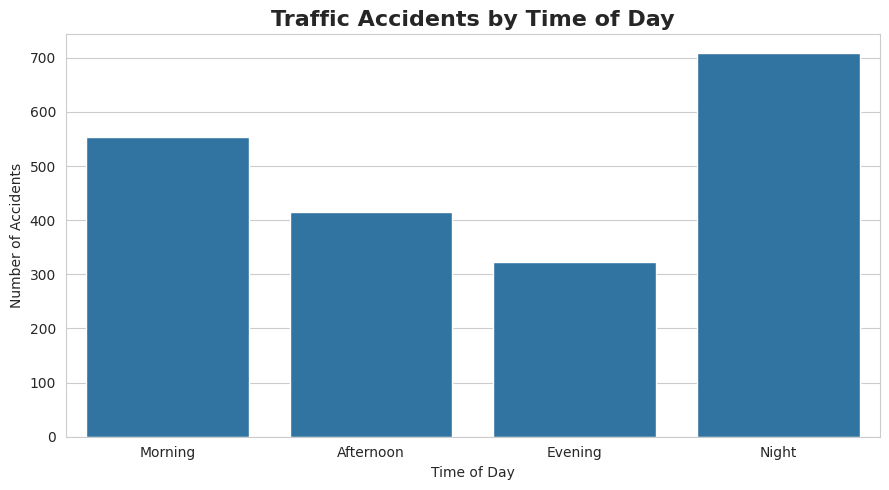

In [13]:
# Bar Chart
plt.figure(figsize=(9,5))
order = ["Morning", "Afternoon", "Evening", "Night"]
sns.countplot(data=df,x="Time_Period",order=order)
plt.title("Traffic Accidents by Time of Day",
          fontsize=16, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

In [14]:
# Analyze Accidents by Weather
weather_counts = df["Weather"].value_counts()
print(weather_counts)

Weather
Clear     899
Cloudy    438
Rainy     410
Foggy     172
Stormy     81
Name: count, dtype: int64


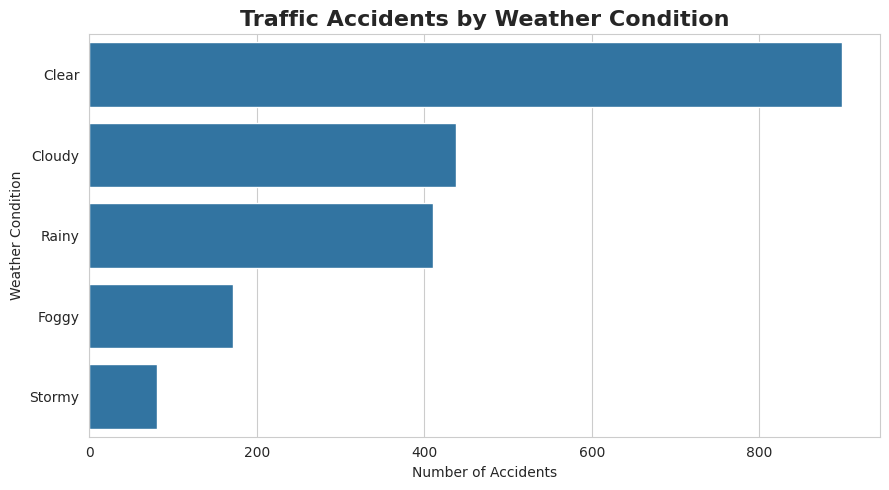

In [15]:
# Visualization
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="Weather",
    order=df["Weather"].value_counts().index
)

plt.title("Traffic Accidents by Weather Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

plt.tight_layout()
plt.show()

In [16]:
# Analyze Accidents by Road Condition
road_counts = df["Road_Condition"].value_counts()
print(road_counts)

Road_Condition
Dry         1197
Wet          512
Poor         152
Slippery     139
Name: count, dtype: int64


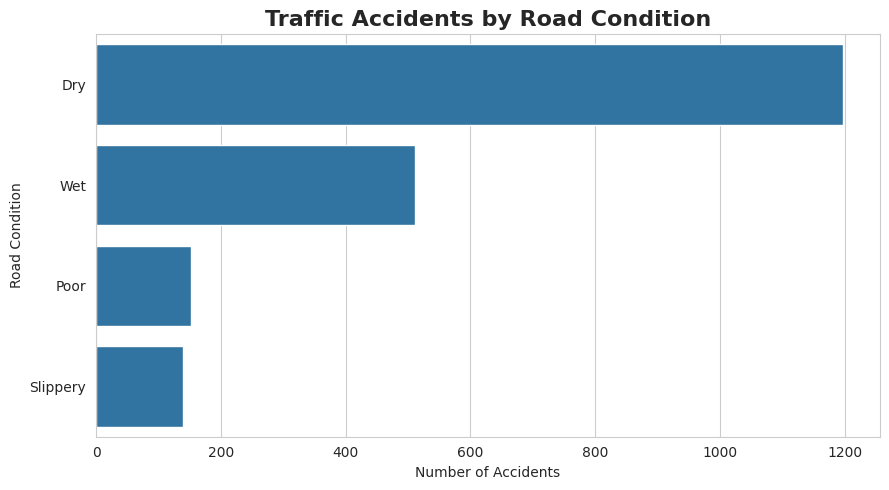

In [17]:
# Visualization
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="Road_Condition",
    order=df["Road_Condition"].value_counts().index
)

plt.title("Traffic Accidents by Road Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Number of Accidents")
plt.ylabel("Road Condition")

plt.tight_layout()
plt.show()

In [18]:
# Weather × Road Condition
weather_road = pd.crosstab(
    df["Weather"],
    df["Road_Condition"]
)

print(weather_road)

Road_Condition  Dry  Poor  Slippery  Wet
Weather                                 
Clear           713    84         0  102
Cloudy          337    43         0   58
Foggy           101    25         0   46
Rainy            41     0       116  253
Stormy            5     0        23   53


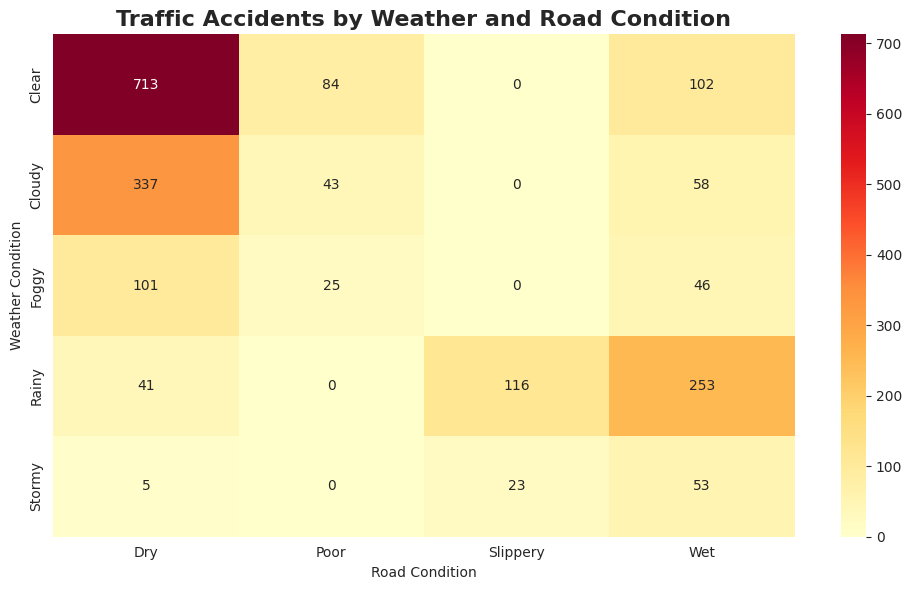

In [19]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    weather_road,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Traffic Accidents by Weather and Road Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Road Condition")
plt.ylabel("Weather Condition")

plt.tight_layout()
plt.show()

In [20]:
# Time of Day × Weather
time_weather = pd.crosstab(
    df["Time_Period"],
    df["Weather"]
)

print(time_weather)

Weather      Clear  Cloudy  Foggy  Rainy  Stormy
Time_Period                                     
Afternoon      171     103     40     81      21
Evening        149      70     24     68      11
Morning        248     113     50    118      25
Night          331     152     58    143      24


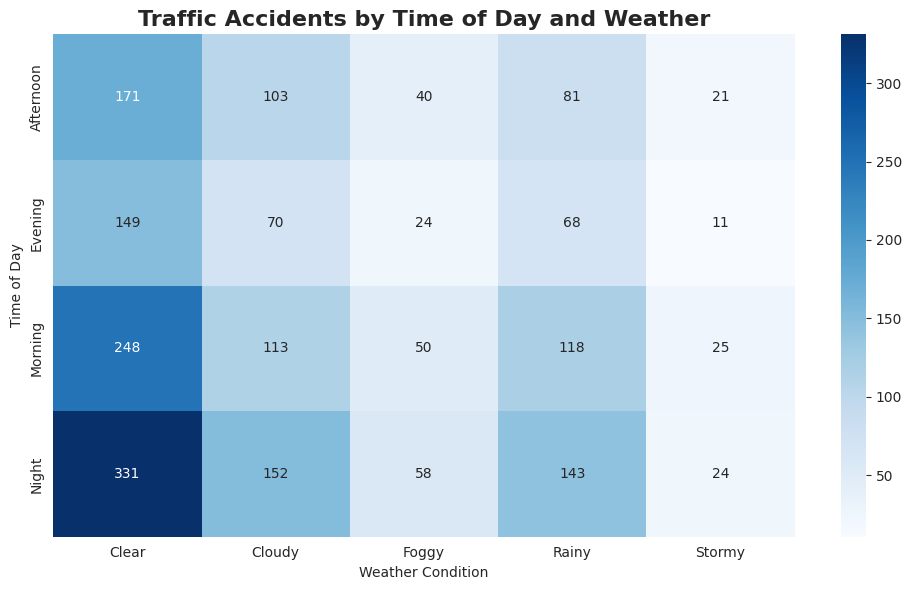

In [21]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    time_weather,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Traffic Accidents by Time of Day and Weather",
          fontsize=16, fontweight="bold")

plt.xlabel("Weather Condition")
plt.ylabel("Time of Day")

plt.tight_layout()
plt.show()

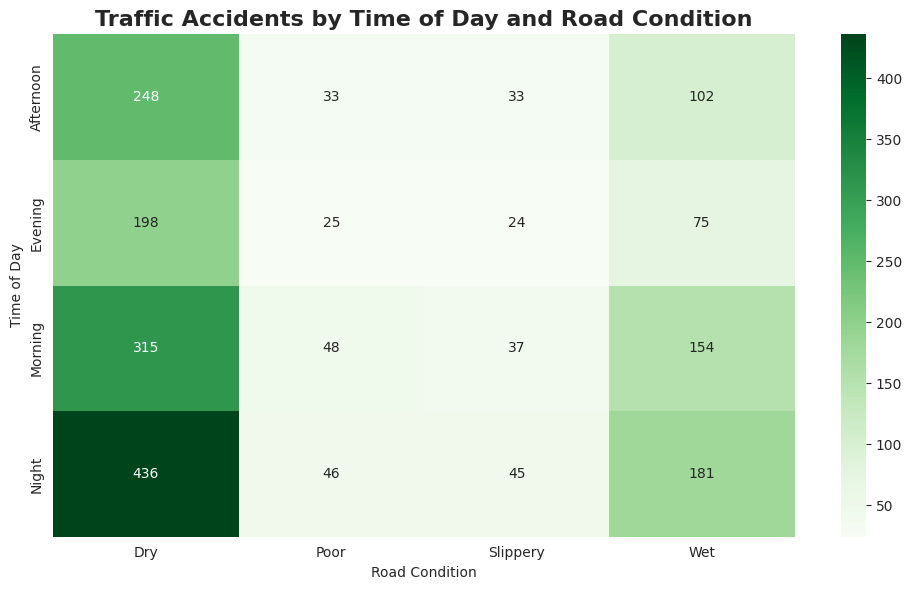

In [22]:
# Time of Day × Road Condition
time_road = pd.crosstab(
    df["Time_Period"],
    df["Road_Condition"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    time_road,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Traffic Accidents by Time of Day and Road Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Road Condition")
plt.ylabel("Time of Day")

plt.tight_layout()
plt.show()

In [23]:
# Analyze Accident Severity
severity_counts = df["Severity"].value_counts()

print(severity_counts)

Severity
Minor       824
Moderate    737
Severe      347
Fatal        92
Name: count, dtype: int64


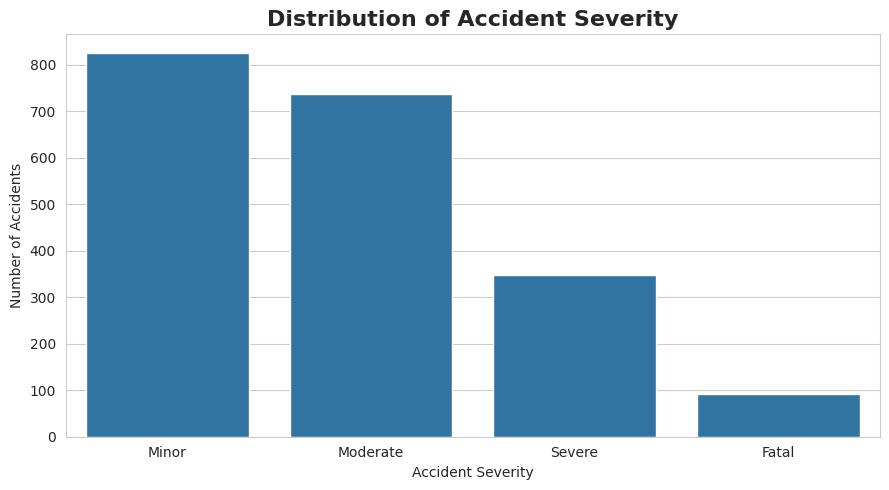

In [24]:
# Visualization
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Severity",
    order=df["Severity"].value_counts().index
)

plt.title("Distribution of Accident Severity",
          fontsize=16, fontweight="bold")

plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

plt.tight_layout()
plt.show()

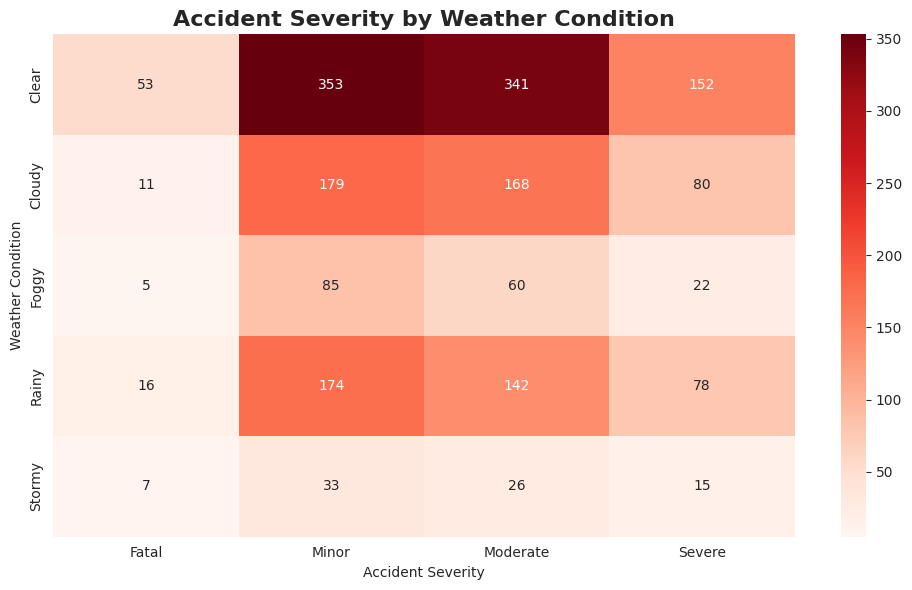

In [25]:
# Weather vs Accident Severity
weather_severity = pd.crosstab(
    df["Weather"],
    df["Severity"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    weather_severity,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Accident Severity by Weather Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Accident Severity")
plt.ylabel("Weather Condition")

plt.tight_layout()
plt.show()

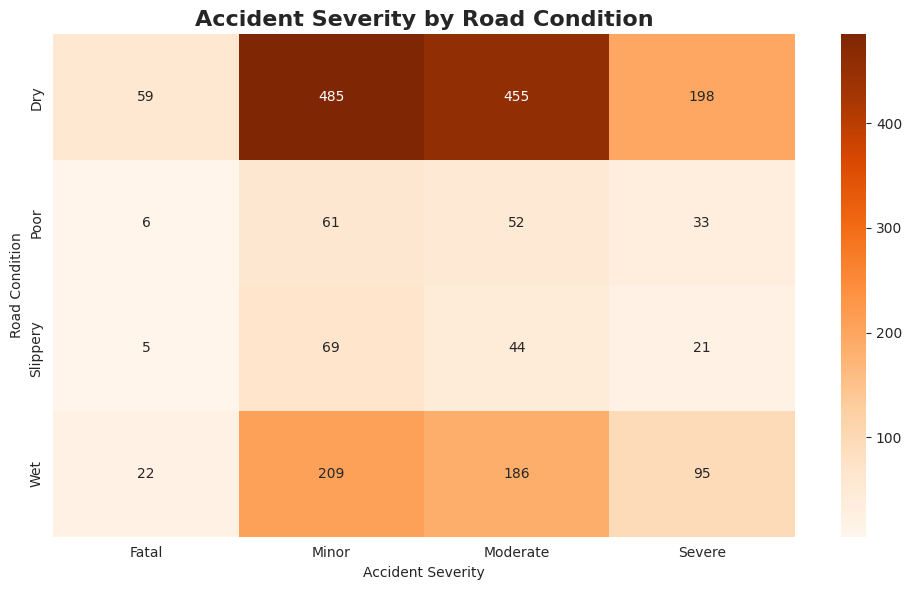

In [26]:
# Road Condition vs Accident Severity
road_severity = pd.crosstab(
    df["Road_Condition"],
    df["Severity"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    road_severity,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Accident Severity by Road Condition",
          fontsize=16, fontweight="bold")

plt.xlabel("Accident Severity")
plt.ylabel("Road Condition")

plt.tight_layout()
plt.show()

In [27]:
# Analyze Accident Locations
print(df[["Location", "Latitude", "Longitude"]].head())

          Location   Latitude  Longitude
0    Junction Road  19.218621  72.772455
1  Industrial Area  19.240612  73.055098
2     College Road  19.149269  72.929786
3     Main Highway  19.039037  72.955836
4     Main Highway  19.147635  72.879950


In [28]:
# Location-wise Accident Analysis
location_counts = df["Location"].value_counts()

print(location_counts)

Location
Residential Area    196
Ring Road           188
Junction Road       179
College Road        179
Industrial Area     175
Main Highway        173
Market Road         159
Bridge Road         159
Station Road        154
City Center         149
Expressway          145
Airport Road        144
Name: count, dtype: int64


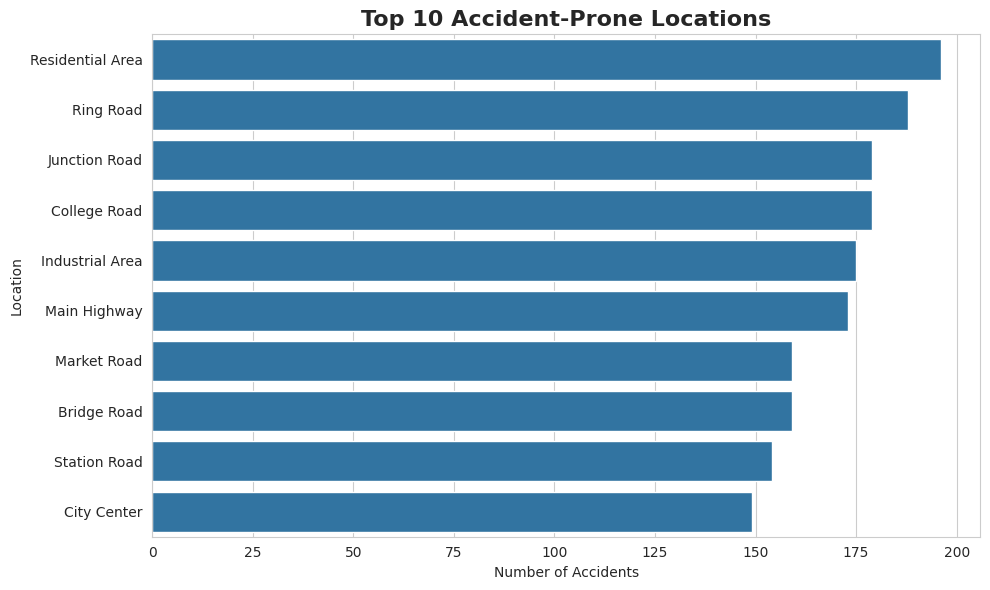

In [29]:
# Top accident locations
plt.figure(figsize=(10,6))

top_locations = df["Location"].value_counts().head(10)

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 10 Accident-Prone Locations",
          fontsize=16, fontweight="bold")

plt.xlabel("Number of Accidents")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [30]:
# Accident Hotspot Map
# Find the average geographical location

center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

# Create map

accident_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11
)

# Prepare coordinates

heat_data = df[
    ["Latitude", "Longitude"]
].dropna().values.tolist()

# Add heatmap

HeatMap(
    heat_data,
    radius=15,
    blur=20,
    min_opacity=0.4
).add_to(accident_map)

accident_map

In [31]:
# Accident Hotspots by Severity
severe_df = df[
    df["Severity"].isin(["Severe", "Fatal"])
]

severe_map = folium.Map(
    location=[
        df["Latitude"].mean(),
        df["Longitude"].mean()
    ],
    zoom_start=11
)

severe_heat_data = severe_df[
    ["Latitude", "Longitude"]
].dropna().values.tolist()

HeatMap(
    severe_heat_data,
    radius=15,
    blur=20
).add_to(severe_map)

severe_map

In [32]:
# Identify Major Contributing Factors
print("========== CONTRIBUTING FACTORS ==========")

print("\n1. Time of Day:")
print(df["Time_Period"].value_counts())

print("\n2. Weather:")
print(df["Weather"].value_counts())

print("\n3. Road Condition:")
print(df["Road_Condition"].value_counts())

print("\n4. Road Type:")
print(df["Road_Type"].value_counts())

print("\n5. Light Condition:")
print(df["Light_Condition"].value_counts())

print("\n6. Accident Severity:")
print(df["Severity"].value_counts())

========== CONTRIBUTING FACTORS ==========

1. Time of Day:
Time_Period
Night        708
Morning      554
Afternoon    416
Evening      322
Name: count, dtype: int64

2. Weather:
Weather
Clear     899
Cloudy    438
Rainy     410
Foggy     172
Stormy     81
Name: count, dtype: int64

3. Road Condition:
Road_Condition
Dry         1197
Wet          512
Poor         152
Slippery     139
Name: count, dtype: int64

4. Road Type:
Road_Type
Urban Road          599
Highway             475
Residential Road    350
Intersection        310
Expressway          266
Name: count, dtype: int64

5. Light Condition:
Light_Condition
Daylight    969
Dark        785
Dusk        246
Name: count, dtype: int64

6. Accident Severity:
Severity
Minor       824
Moderate    737
Severe      347
Fatal        92
Name: count, dtype: int64


In [33]:
# Find the Highest Accident Categories Automatically
highest_time = df["Time_Period"].value_counts().idxmax()
highest_weather = df["Weather"].value_counts().idxmax()
highest_road = df["Road_Condition"].value_counts().idxmax()
highest_road_type = df["Road_Type"].value_counts().idxmax()
highest_light = df["Light_Condition"].value_counts().idxmax()
highest_severity = df["Severity"].value_counts().idxmax()

print("Highest accident time period:", highest_time)
print("Most common weather condition:", highest_weather)
print("Most common road condition:", highest_road)
print("Most common road type:", highest_road_type)
print("Most common light condition:", highest_light)
print("Most common accident severity:", highest_severity)

Highest accident time period: Night
Most common weather condition: Clear
Most common road condition: Dry
Most common road type: Urban Road
Most common light condition: Daylight
Most common accident severity: Minor


In [34]:
# Create a Final Summary Table
summary = pd.DataFrame({
    "Factor": [
        "Time of Day",
        "Weather",
        "Road Condition",
        "Road Type",
        "Light Condition",
        "Accident Severity"
    ],
    "Highest Category": [
        highest_time,
        highest_weather,
        highest_road,
        highest_road_type,
        highest_light,
        highest_severity
    ]
})

summary

,Factor,Highest Category
0,Time of Day,Night
1,Weather,Clear
2,Road Condition,Dry
3,Road Type,Urban Road
4,Light Condition,Daylight
5,Accident Severity,Minor


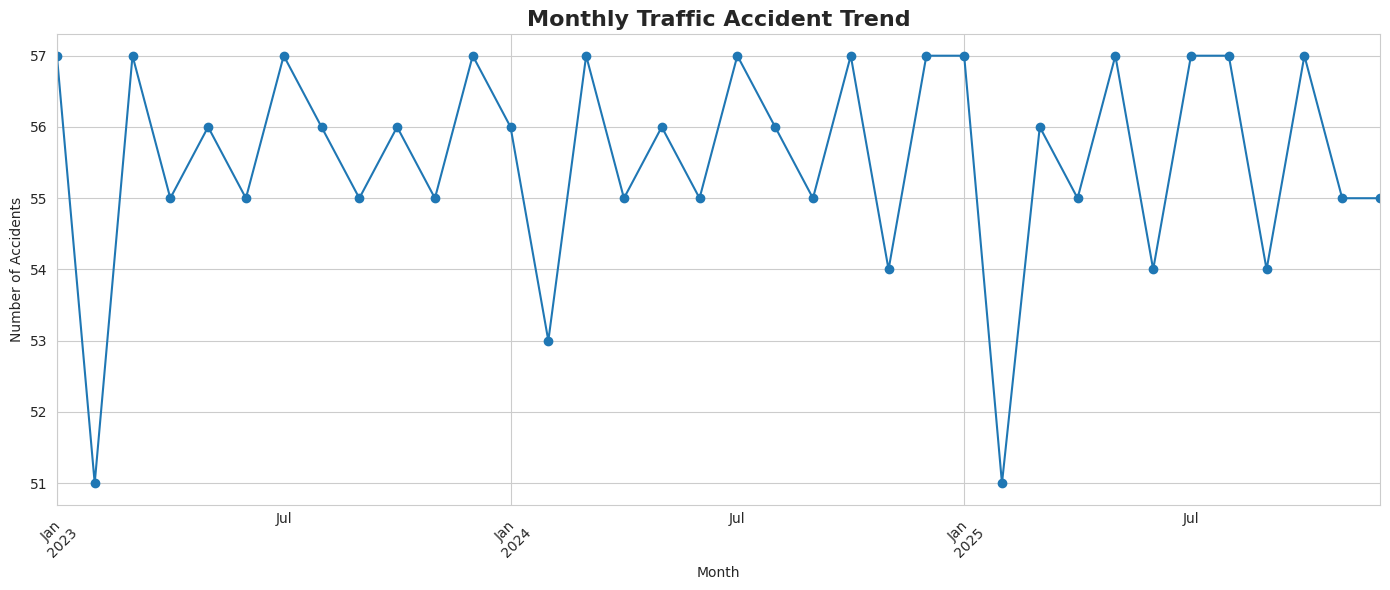

In [35]:
# Analyze Monthly Accident Trends
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

monthly_accidents = df.groupby(
    df["Date"].dt.to_period("M")
).size()

plt.figure(figsize=(14,6))

monthly_accidents.plot(kind="line", marker="o")

plt.title("Monthly Traffic Accident Trend",
          fontsize=16, fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()